2D畳み込みカーネル行列 K_eff を計算中... (1Dの約7倍の時間がかかります)
計算完了！
逆問題解析を開始します...
反復 2回で収束 (Chi^2 = 0.335)


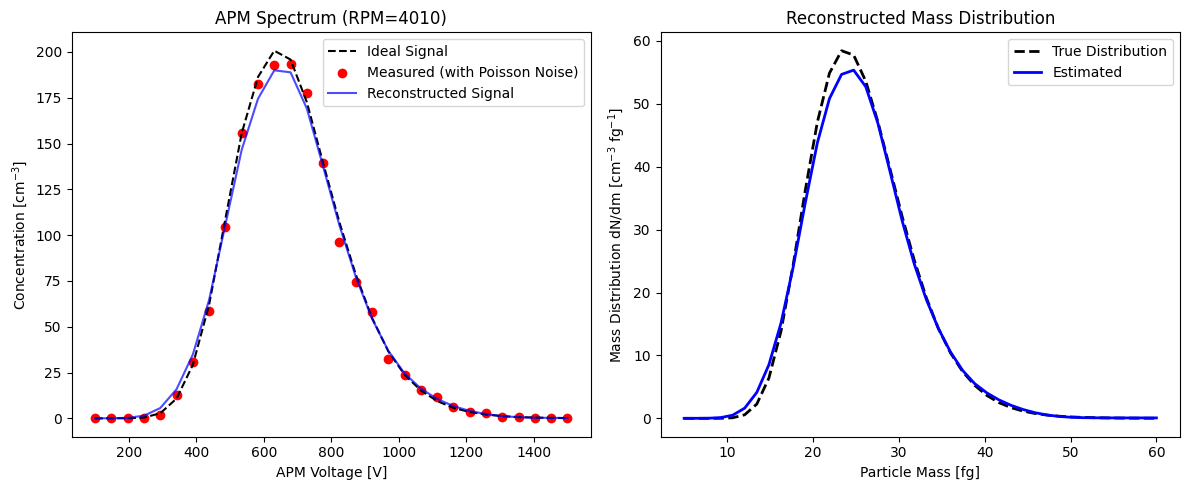

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# ==========================================
# 1. 物理定数とAPM/DMAの条件設定
# ==========================================
e = 1.60219e-19       
vis = 1.83e-5         
P = 1.013e5           
PI = np.pi

L = 100.0e-3          
r1 = 24.0e-3          
r2 = 25.0e-3          
rc = 0.5 * (r1 + r2)  
delta = 0.5 * (r2 - r1) 

Q_a_lpm = 0.3         
Q = Q_a_lpm * 1e-3 / 60.0 

RPM = 4000  #[rpm]

omega = RPM / 60.0 * 2.0 * PI 

# DMA条件
Dmob = 450.0e-9          # [m]
Cc_star = 1.0 + 1.0 / (P * 1e-3 * Dmob * 1e6) * \
          (15.60 + 7.00 * np.exp(-0.059 * (P * 1e-3 * Dmob * 1e6)))

# ★中心の電気移動度 Zp_star を計算
Zp_star = (e * Cc_star) / (3.0 * PI * vis * Dmob)

# DMAの分解能 (Sample 0.3 / Sheath 3.0 lpm の場合 0.1)
beta = 0.1

Q_cpc_ccps = (0.3 * 1000) / 60.0  
t_meas = 1   # 各電圧ステップでのサンプリング時間 [s]
V_sample = Q_cpc_ccps * t_meas # 1ステップあたりの吸引体積 [cm^3]

dz = 1.0e-4 
nr0 = 1000


# ==============================================================================
# 2. APM透過率関数 (★引数に Zp を追加し、Zpベースの運動方程式に変更)
# ==============================================================================
def calc_transfer_efficiency(m, V, Zp):
    r0 = np.linspace(r1 + 1e-5, r2 - 1e-5, nr0) 
    r = r0.copy()
    
    weights = 1.5 * (1.0 - ((r0 - rc) / delta)**2)
    total_weight = np.sum(weights)
    
    # ★ Cc/Dmob を Zp に置き換えた係数 (Zp = e*Cc / 3*pi*vis*Dmob より)
    coef = dz * (8.0 / 3.0) * (PI * Zp / e) * (delta * rc) / Q
    V_term = e * V / np.log(r2 / r1)
    
    active = np.ones(nr0, dtype=bool) 
    num_steps = int(L / dz)
    
    for _ in range(num_steps):
        if not np.any(active): break
        ra = r[active]
        def f(rad):
            return coef * (m * omega**2 * rad - V_term / rad) / (1.0 - ((rad - rc) / delta)**2)
        
        k1 = f(ra)
        k2 = f(ra + 0.5 * k1)
        k3 = f(ra + 0.5 * k2)
        k4 = f(ra + k3)
        r[active] = ra + (k1 + 2.0*k2 + 2.0*k3 + k4) / 6.0
        active[active] = np.abs(r[active] - rc) < (delta - 1e-5)

    return np.sum(weights[active]) / total_weight


# ==============================================================================
# 3. 畳み込みカーネル行列 K_eff の構築 (2D -> 1D)
# ==============================================================================
V_array = np.linspace(100, 1500, 30)
I = len(V_array)

m_min, m_max = 5.0e-18, 8.0e-17  # 5 fg ~ 80 fg [kg]
J = 40
m_array = np.linspace(m_min, m_max, J)
dm = m_array[1] - m_array[0]    

# ★ DMAの透過率関数(三角形)を離散化して準備 (積分用グリッド)
num_Zp_bins = 7 # 7分割程度で十分な精度が出ます
Zp_array = np.linspace(Zp_star * (1.0 - beta), Zp_star * (1.0 + beta), num_Zp_bins)
Omega_DMA = np.maximum(0.0, 1.0 - np.abs(Zp_array - Zp_star) / (beta * Zp_star))
sum_Omega_DMA = np.sum(Omega_DMA)

print("2D畳み込みカーネル行列 K_eff を計算中... (1Dの約7倍の時間がかかります)")
K = np.zeros((I, J))
for i, V in enumerate(V_array):
    for j, m in enumerate(m_array):
        
        # ★ Zpで積分 (Omega_APM と Omega_DMA の積和)
        K_eff_val = 0.0
        for zp, w_dma in zip(Zp_array, Omega_DMA):
            if w_dma > 0:
                omega_apm = calc_transfer_efficiency(m, V, zp)
                K_eff_val += omega_apm * w_dma
                
        # 最後にDMAの重みで割って平均化し、質量グリッド幅 dm を掛ける
        K[i, j] = (K_eff_val / sum_Omega_DMA) * dm
        
print("計算完了！")


# ==========================================
# 4. 模擬データの生成 (ポアソンノイズの厳密化)
# ==========================================
# 真の質量分布 dN/dm (積分して総濃度が約800 cm^-3になるよう設定)
true_m_center = 2.5e-17
sigma_g = 1.25
f_true = lognorm.pdf(m_array, s=np.log(sigma_g), scale=true_m_center)
f_true = f_true / np.sum(f_true * dm) * 800.0 # 総濃度 800 cm^-3

# 理想的な濃度 [cm^-3]
n_ideal = K @ f_true

# ★修正3: カウント数ベースでのポアソンノイズ付加
count_ideal = n_ideal * V_sample
np.random.seed(42)
count_meas = np.random.poisson(count_ideal)
n_meas = count_meas / V_sample # 濃度 [cm^-3] に戻す

# ==========================================
# 5. Chahine-Twomey 法 (Markowski平滑化つき)
# ==========================================
def solve_chahine_twomey(K_matrix, meas_data, max_iter=1000, chi_threshold=1.0):
    # 初期推測 (一様分布)
    f_est = np.ones(J) * (np.sum(meas_data) / (m_max - m_min))
    K_norm = K_matrix / np.max(K_matrix)

    print("逆問題解析を開始します...")
    for k in range(max_iter):
        calc_n = K_matrix @ f_est
        calc_n = np.maximum(calc_n, 1e-10)

        # カイ二乗値 (ポアソン統計に基づく重み)
        chi_sq = np.sum(((meas_data - calc_n)**2) / np.maximum(calc_n, 1.0/V_sample)) / I
        if chi_sq < chi_threshold:
            print(f"反復 {k}回で収束 (Chi^2 = {chi_sq:.3f})")
            break

        # ★修正1: Chahine型の更新式 (加重平均)
        ratio = meas_data / calc_n
        f_new = np.copy(f_est)
        for j in range(J):
            correction = np.sum(ratio * K_norm[:, j]) / max(np.sum(K_norm[:, j]), 1e-10)
            f_new[j] = f_est[j] * max(correction, 0.01)

        # 内部平滑化 (1-2-1 移動平均)
        f_smooth = np.copy(f_new)
        f_smooth[1:-1] = 0.25 * f_new[:-2] + 0.5 * f_new[1:-1] + 0.25 * f_new[2:]
        f_est = np.copy(f_smooth)

    else:
        print(f"最大反復回数 {max_iter} に到達 (Chi^2 = {chi_sq:.3f})")

    return f_est

# 解析の実行
f_estimated = solve_chahine_twomey(K, n_meas)

# 最終的な推定質量分布(f_estimated)を用いて、順問題により再構成APMスペクトルを厳密に計算する
n_reconstructed = K @ f_estimated

# ==========================================
# 6. 結果のプロット
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(V_array, n_ideal, 'k--', label='Ideal Signal')
ax1.scatter(V_array, n_meas, color='red', label='Measured (with Poisson Noise)')
ax1.plot(V_array, n_reconstructed, 'b-', alpha=0.7, label='Reconstructed Signal')
ax1.set_xlabel('APM Voltage [V]')
ax1.set_ylabel('Concentration [cm$^{-3}$]')
ax1.set_title('APM Spectrum (RPM=4010)')
ax1.legend()

# 質量分布のプロット (dN/dm [cm^-3 / fg] に単位換算して見やすくする)
ax2.plot(m_array * 1e18, f_true * 1e-18, 'k--', linewidth=2, label='True Distribution')
ax2.plot(m_array * 1e18, f_estimated * 1e-18, 'b-', linewidth=2, label='Estimated')
ax2.set_xlabel('Particle Mass [fg]')
ax2.set_ylabel('Mass Distribution dN/dm [cm$^{-3}$ fg$^{-1}$]')
ax2.set_title('Reconstructed Mass Distribution')
ax2.legend()

plt.tight_layout()
plt.show()